# <center>A Mechine Learning Approach for predicting Customer Churn in the Telecom Industry</center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import GridSearchCV, cross_val_score

C:\Users\prais\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#pip install imbalanced-learn

In [2]:
df=pd.read_csv(r"C:\Users\prais\Downloads\pr data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### DATA UNDERSTANDING

In [3]:
df.size

147903

In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [8]:
df['TotalCharges'].unique()

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean(),inplace=True)

C:\Users\prais\AppData\Local\Temp\ipykernel_21032\1399715742.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean(),inplace=True)


In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

### EDA

#### Churn Distribution

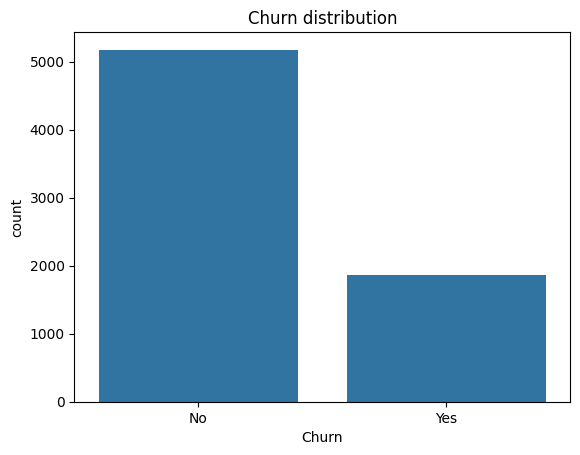

In [16]:
sns.countplot(x='Churn',data=df)
plt.title('Churn distribution')
plt.show()

#### Categorical features VS Churn

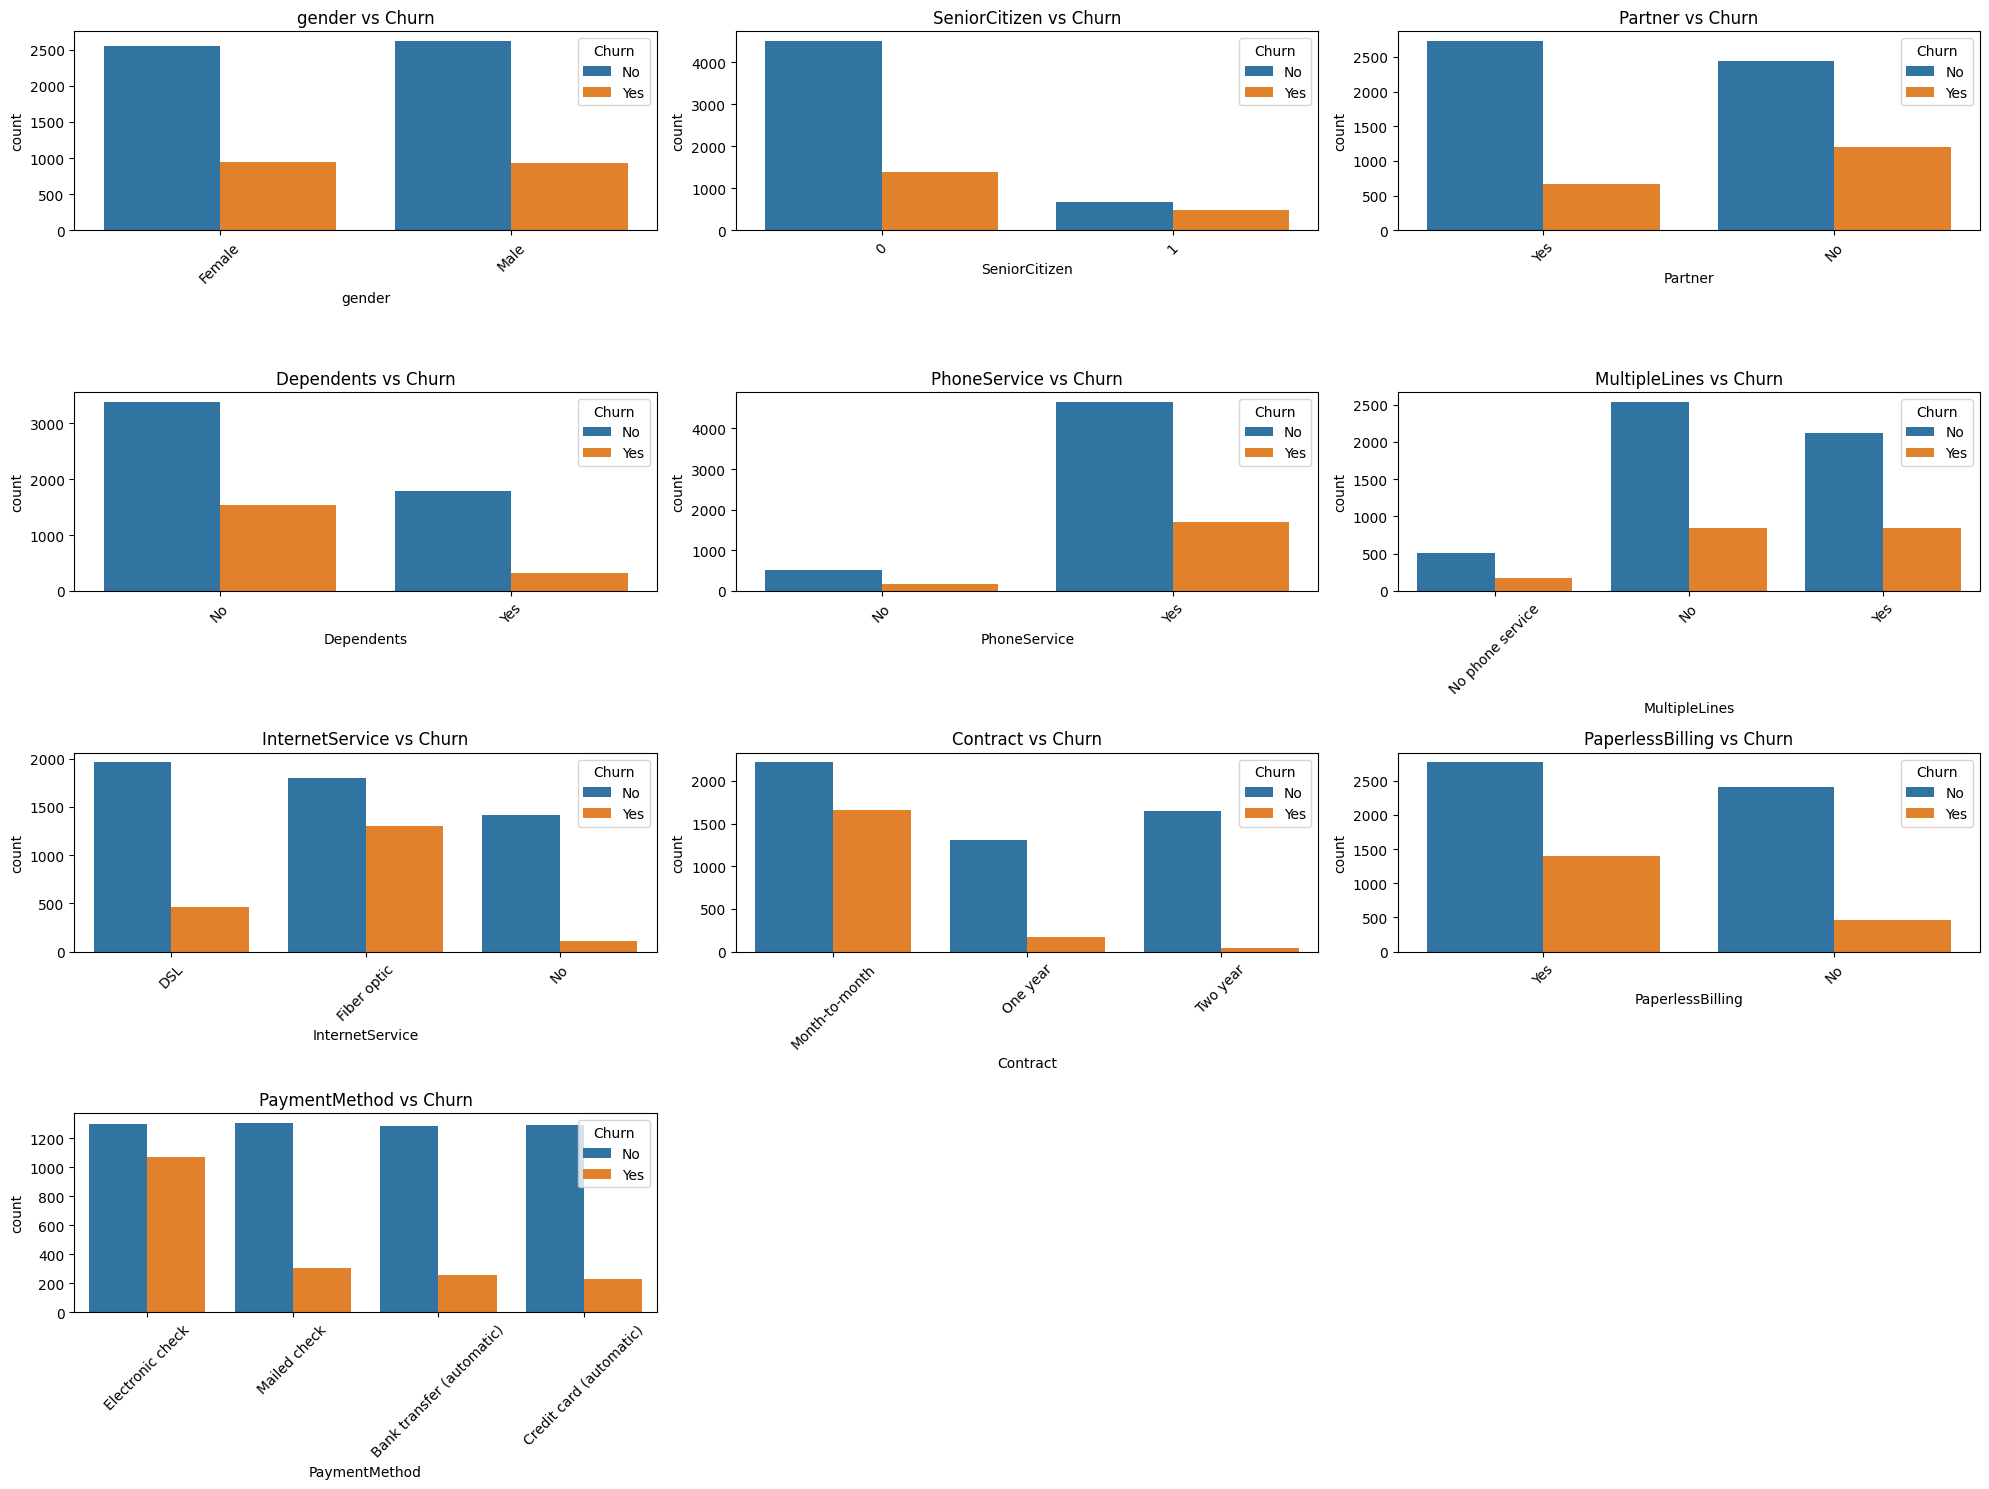

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

#### Neumerical features VS Churn

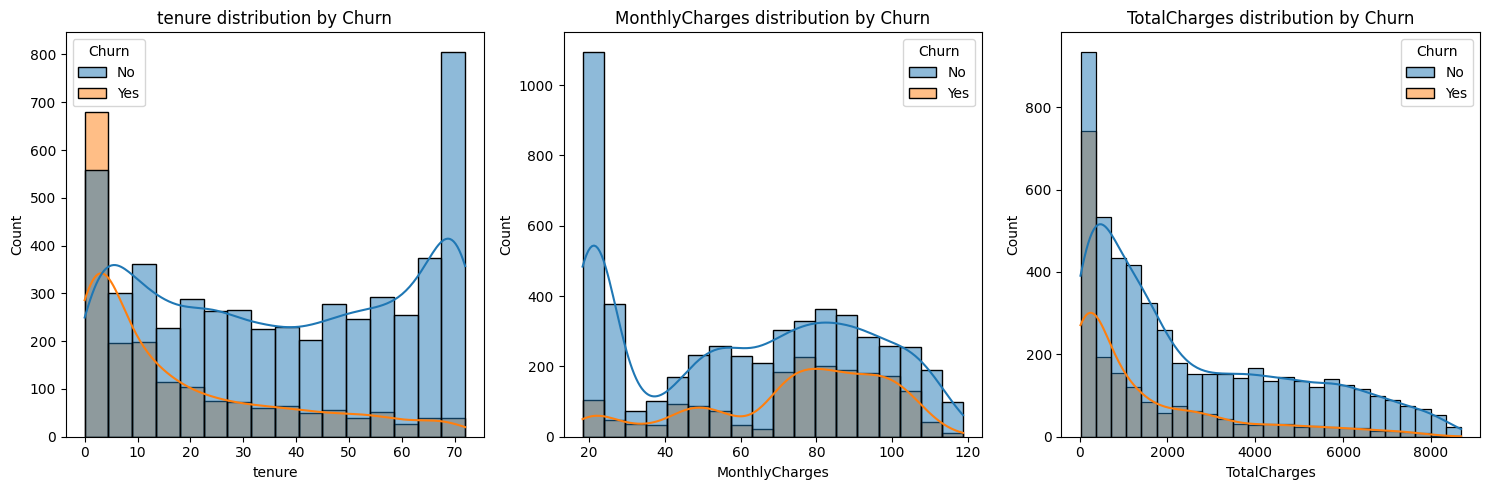

In [18]:
plt.figure(figsize=(15,5))
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(numerical_cols,1):
    plt.subplot(1,3,i)
    sns.histplot(data=df, x=col, hue='Churn', kde=True)
    plt.title(f'{col} distribution by Churn')

plt.tight_layout()
plt.show()

#### Correlation map

In [19]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

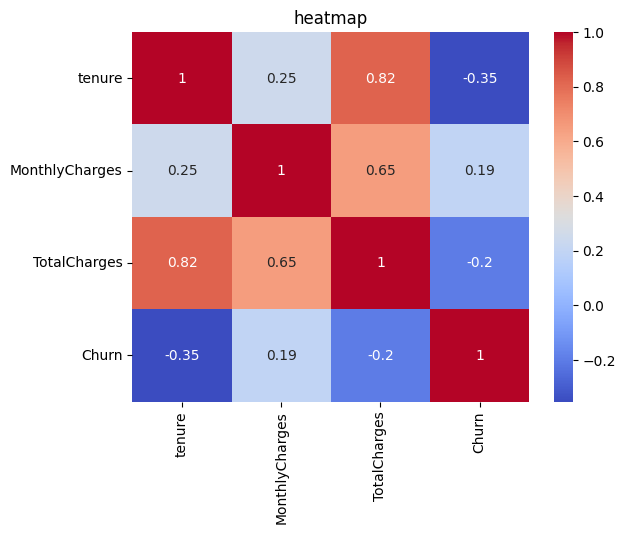

In [20]:
df1=df[['tenure','MonthlyCharges','TotalCharges','Churn']]
corr=df1.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('heatmap')
plt.show()

In [21]:
df['gender'].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

### DATA PREPROCESSING

#### Outlier detection

In [22]:
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(col,"outliers:",outliers.shape[0])

tenure outliers: 0
MonthlyCharges outliers: 0
TotalCharges outliers: 0


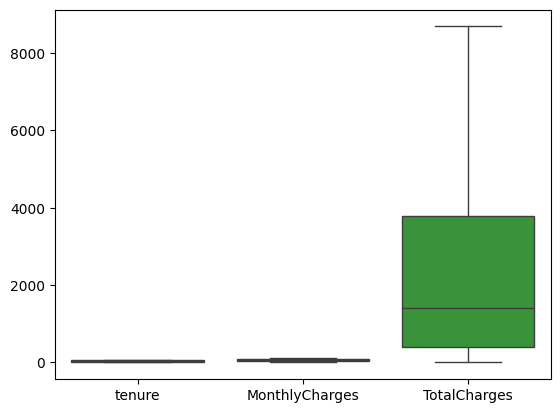

In [23]:
sns.boxplot(data=df[['tenure', 'MonthlyCharges', 'TotalCharges']])
plt.show()

#### Encoding

In [24]:
encode=LabelEncoder()
df['gender']=encode.fit_transform(df['gender'])
df['Partner']=encode.fit_transform(df['Partner'])
df['Dependents']=encode.fit_transform(df['Dependents'])
df['PhoneService']=encode.fit_transform(df['PhoneService'])
df['MultipleLines']=encode.fit_transform(df['MultipleLines'])
df['InternetService']=encode.fit_transform(df['InternetService'])
df['OnlineSecurity']=encode.fit_transform(df['OnlineSecurity'])
df['OnlineBackup']=encode.fit_transform(df['OnlineBackup'])
df['DeviceProtection']=encode.fit_transform(df['DeviceProtection'])
df['TechSupport']=encode.fit_transform(df['TechSupport'])
df['StreamingTV']=encode.fit_transform(df['StreamingTV'])
df['StreamingMovies']=encode.fit_transform(df['StreamingMovies'])
df['Contract']=encode.fit_transform(df['Contract'])
df['PaperlessBilling']=encode.fit_transform(df['PaperlessBilling'])
df['PaymentMethod']=encode.fit_transform(df['PaymentMethod'])


In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [26]:
print(df.dtypes)

customerID              str
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [27]:
df.drop('customerID',axis=1,inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


### X,Y Seperation

In [28]:
x=df.drop('Churn',axis=1)
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [29]:
x.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [30]:
y=df['Churn']
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

### Spliting of data

In [31]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

### Scaling

In [32]:
std_scaler=StandardScaler()
xtrain_std=std_scaler.fit_transform(xtrain)
xtest_std=std_scaler.transform(xtest)

#### Logistic Regression

In [33]:
m1=LogisticRegression()
m1.fit(xtrain_std,ytrain)
ypred1=m1.predict(xtest_std)
ypred1

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [34]:
trpred1=m1.predict(xtrain_std)
trpred1

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [35]:
lt=accuracy_score(ytest,ypred1)
lt

0.8161816891412349

In [36]:
lr=accuracy_score(ytrain,trpred1)
lr

0.8006744763933262

In [37]:
cm1=confusion_matrix(ytest,ypred1)
cm1

array([[933, 103],
       [156, 217]])

In [38]:
cs1=classification_report(ytest,ypred1)
print(cs1)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



### SVC

In [39]:
m2=SVC()
m2.fit(xtrain_std,ytrain)
ypred2=m2.predict(xtest_std)
ypred2

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [40]:
trpred2=m2.predict(xtrain_std)
trpred2

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [41]:
st=accuracy_score(ytest,ypred2)
st

0.8069552874378992

In [42]:
sr=accuracy_score(ytrain,trpred2)
sr

0.8193113241036564

In [43]:
cm2=confusion_matrix(ytest,ypred2)
cm2

array([[950,  86],
       [186, 187]])

In [44]:
cs2=classification_report(ytest,ypred2)
print(cs2)

              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



### KNN Classifier

In [45]:
m3=KNeighborsClassifier(n_neighbors=30)
m3.fit(xtrain_std,ytrain)
ypred3=m3.predict(xtest_std)
ypred3

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [46]:
trpred3=m3.predict(xtrain_std)
trpred3

array([0, 0, 0, ..., 0, 1, 0], shape=(5634,))

In [47]:
kt=accuracy_score(ytest,ypred3)
kt

0.7955997161107168

In [48]:
kr=accuracy_score(ytrain,trpred3)
kr

0.7971246006389776

In [49]:
cm3=confusion_matrix(ytest,ypred3)
cm3

array([[914, 122],
       [166, 207]])

In [50]:
cs3=classification_report(ytest,ypred3)
print(cs3)

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.63      0.55      0.59       373

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



### GaussianNB Classifier

In [51]:
m4=GaussianNB()
m4.fit(xtrain_std,ytrain)
ypred4=m4.predict(xtest_std)
ypred4

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [52]:
trpred4=m4.predict(xtrain_std)
trpred4

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [53]:
gt=accuracy_score(ytest,ypred4)
gt

0.7579843860894251

In [54]:
gr=accuracy_score(ytrain,trpred4)
gr

0.7511537096201633

In [55]:
cm4=confusion_matrix(ytest,ypred4)
cm4

array([[779, 257],
       [ 84, 289]])

In [56]:
cs4=classification_report(ytest,ypred4)
print(cs4)

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1036
           1       0.53      0.77      0.63       373

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### Decision Tree Classifier

In [57]:
m5=DecisionTreeClassifier()
m5.fit(xtrain_std,ytrain)
ypred5=m5.predict(xtest_std)
ypred5

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [58]:
trpred5=m5.predict(xtrain_std)
trpred5

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [59]:
dt=accuracy_score(ytest,ypred5)
dt

0.7338537970191625

In [60]:
dr=accuracy_score(ytrain,trpred5)
dr

0.9985800496982605

In [61]:
cm5=confusion_matrix(ytest,ypred5)
cm5

array([[846, 190],
       [185, 188]])

In [62]:
cs5=classification_report(ytest,ypred5)
print(cs5)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1036
           1       0.50      0.50      0.50       373

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.73      0.73      1409



### RandomForest Classifier

In [63]:
m6=RandomForestClassifier(n_estimators=50,random_state=42)
m6.fit(xtrain_std,ytrain)
ypred6=m6.predict(xtest_std)
ypred6

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [64]:
trpred6=m6.predict(xtrain_std)
trpred6

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [65]:
rt=accuracy_score(ytest,ypred6)
rt

0.7913413768630234

In [66]:
rr=accuracy_score(ytrain,trpred6)
rr

0.9976925807596734

In [67]:
cm6=confusion_matrix(ytest,ypred6)
cm6

array([[946,  90],
       [204, 169]])

In [68]:
cs6=classification_report(ytest,ypred6)
print(cs6)

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### AdaBoostClassifier

In [69]:
m7=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=50,learning_rate=1.0,random_state=42)
m7.fit(xtrain_std,ytrain)
ypred7=m7.predict(xtest_std)
ypred7

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [70]:
trpred7=m7.predict(xtrain_std)
trpred7

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [71]:
at=accuracy_score(ytest,ypred7)
at

0.8062455642299503

In [72]:
ar=accuracy_score(ytrain,trpred7)
ar

0.8044018459353922

In [73]:
cm7=confusion_matrix(ytest,ypred7)
cm7

array([[932, 104],
       [169, 204]])

In [74]:
cs7=classification_report(ytest,ypred7)
print(cs7)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.66      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### GradientBoosting Classifier

In [75]:
m8=GradientBoostingClassifier(n_estimators=50,learning_rate=0.1,max_depth=3,random_state=42)
m8.fit(xtrain_std,ytrain)
ypred8=m8.predict(xtest_std)
ypred8

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [76]:
trpred8=m8.predict(xtrain_std)
trpred8

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [77]:
gt1=accuracy_score(ytest,ypred8)
gt1

0.8048261178140526

In [78]:
gr1=accuracy_score(ytrain,trpred8)
gr1

0.8170039048633297

In [79]:
cm8=confusion_matrix(ytest,ypred8)
cm8

array([[944,  92],
       [183, 190]])

In [80]:
cs8=classification_report(ytest,ypred8)
print(cs8)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.51      0.58       373

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### XGBoost Classifier

In [81]:
m9=xgb.XGBClassifier(objective='binary:logistic',learning_rate=0.1,max_depth=4,n_estimators=50)
m9.fit(xtrain_std,ytrain)
ypred9=m9.predict(xtest_std)
ypred9

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [82]:
trpred9=m9.predict(xtrain_std)
trpred9

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [83]:
xt=accuracy_score(ytest,ypred9)
xt

0.8147622427253371

In [84]:
xr=accuracy_score(ytrain,trpred9)
xr

0.8184238551650692

In [85]:
cm9=confusion_matrix(ytest,ypred9)
cm9

array([[945,  91],
       [170, 203]])

In [86]:
cs9=classification_report(ytest,ypred9)
print(cs9)

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.54      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



In [87]:
models = ["Logistic regression","SVC","KNN","GaussianNB","Decisiontree","Randomforest","Adaboost","Gradientboosting","XGboost"]
tr_score=[lr,sr,kr,gr,dr,rr,ar,gr1,xr]
tt_score=[lt,st,kt,gt,dt,rt,at,gt1,xt]
s=pd.DataFrame({"Models":models,"train_score":tr_score,"test_score":tt_score})
s

,Models,train_score,test_score
0,Logistic regression,0.800674,0.816182
1,SVC,0.819311,0.806955
2,KNN,0.797125,0.795600
3,GaussianNB,0.751154,0.757984
4,Decisiontree,0.998580,0.733854
5,Randomforest,0.997693,0.791341
6,Adaboost,0.804402,0.806246
7,Gradientboosting,0.817004,0.804826
8,XGboost,0.818424,0.814762


## <center> AFTER BALANCING</center>

In [88]:
smote=SMOTE(random_state=42)
xtrainb,ytrainb=smote.fit_resample(xtrain_std,ytrain)

### Logistic regression

In [89]:
mb1=LogisticRegression()
mb1.fit(xtrainb,ytrainb)
ypredb1=mb1.predict(xtest_std)
ypredb1

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [90]:
trpredb1=mb1.predict(xtrainb)
trpredb1

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [91]:
ltb=accuracy_score(ytest,ypredb1)
ltb

0.759403832505323

In [92]:
lrb=accuracy_score(ytrainb,trpredb1)
lrb

0.7717496375060415

In [93]:
cmb1=confusion_matrix(ytest,ypredb1)
cmb1

array([[761, 275],
       [ 64, 309]])

In [94]:
csb1=classification_report(ytest,ypredb1)
print(csb1)

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



### SVC

In [95]:
mb2=SVC()
mb2.fit(xtrainb,ytrainb)
ypredb2=mb2.predict(xtest_std)
ypredb2

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [96]:
trpredb2=mb2.predict(xtrainb)
trpredb2

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [97]:
stb=accuracy_score(ytest,ypredb2)
stb

0.758694109297374

In [98]:
srb=accuracy_score(ytrainb,trpredb2)
srb

0.8360318994683422

In [99]:
cmb2=confusion_matrix(ytest,ypredb2)
cmb2

array([[805, 231],
       [109, 264]])

In [100]:
csb2=classification_report(ytest,ypredb2)
print(csb2)

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1036
           1       0.53      0.71      0.61       373

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



### KNN 

In [101]:
mb3=KNeighborsClassifier(n_neighbors=30)
mb3.fit(xtrainb,ytrainb)
ypredb3=mb3.predict(xtest_std)
ypredb3

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [102]:
trpredb3=mb3.predict(xtrainb)
trpredb3

array([0, 1, 1, ..., 1, 0, 1], shape=(8276,))

In [103]:
ktb=accuracy_score(ytest,ypredb3)
ktb

0.6933995741660752

In [104]:
krb=accuracy_score(ytrainb,trpredb3)
krb

0.7669163847269213

In [105]:
cmb3=confusion_matrix(ytest,ypredb3)
cmb3

array([[661, 375],
       [ 57, 316]])

In [106]:
csb3=classification_report(ytest,ypredb3)
print(csb3)

              precision    recall  f1-score   support

           0       0.92      0.64      0.75      1036
           1       0.46      0.85      0.59       373

    accuracy                           0.69      1409
   macro avg       0.69      0.74      0.67      1409
weighted avg       0.80      0.69      0.71      1409



### GaussianNB

In [107]:
mb4=GaussianNB()
mb4.fit(xtrainb,ytrainb)
ypredb4=mb4.predict(xtest_std)
ypredb4

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [108]:
trpredb4=mb4.predict(xtrainb)
trpredb4

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [109]:
gtb=accuracy_score(ytest,ypredb4)
gtb

0.7388218594748048

In [110]:
grb=accuracy_score(ytrainb,trpredb4)
grb

0.7561623972933784

In [111]:
cmb4=confusion_matrix(ytest,ypredb4)
cmb4

array([[736, 300],
       [ 68, 305]])

In [112]:
csb4=classification_report(ytest,ypredb4)
print(csb4)

              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1036
           1       0.50      0.82      0.62       373

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409



### Decision Tree

In [113]:
mb5=DecisionTreeClassifier(random_state=42)
mb5.fit(xtrainb,ytrainb)
ypredb5=mb5.predict(xtest_std)
ypredb5

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [114]:
trpredb5=mb5.predict(xtrainb)
trpredb5

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [115]:
dtb=accuracy_score(ytest,ypredb5)
dtb

0.7366926898509581

In [116]:
drb=accuracy_score(ytrainb,trpredb5)
drb

0.9990333494441759

In [117]:
cmb5=confusion_matrix(ytest,ypredb5)
cmb5

array([[833, 203],
       [168, 205]])

In [118]:
csb5=classification_report(ytest,ypredb5)
print(csb5)

              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1036
           1       0.50      0.55      0.52       373

    accuracy                           0.74      1409
   macro avg       0.67      0.68      0.67      1409
weighted avg       0.74      0.74      0.74      1409



### Random Forest

In [119]:
mb6=RandomForestClassifier(n_estimators=50,random_state=42)
mb6.fit(xtrainb,ytrainb)
ypredb6=mb6.predict(xtest_std)
ypredb6

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [120]:
trpredb6=mb6.predict(xtrainb)
trpredb6

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [121]:
rtb=accuracy_score(ytest,ypredb6)
rtb

0.7792760823278921

In [122]:
rrb=accuracy_score(ytrainb,trpredb6)
rrb

0.9990333494441759

In [123]:
cmb6=confusion_matrix(ytest,ypredb6)
cmb6

array([[884, 152],
       [159, 214]])

In [124]:
csb6=classification_report(ytest,ypredb6)
print(csb6)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.57      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



### Adaboost

In [125]:
mb7=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=50,learning_rate=1.0,random_state=42)
mb7.fit(xtrainb,ytrainb)
ypredb7=mb7.predict(xtest_std)
ypredb7

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [126]:
trpredb7=mb7.predict(xtrainb)
trpredb7

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [127]:
atb=accuracy_score(ytest,ypredb7)
atb

0.7693399574166075

In [128]:
arb=accuracy_score(ytrainb,trpredb7)
arb

0.8015949734171097

In [129]:
cmb7=confusion_matrix(ytest,ypredb7)
cmb7

array([[787, 249],
       [ 76, 297]])

In [130]:
csb7=classification_report(ytest,ypredb7)
print(csb7)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.80      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



### Gradientboosting

In [131]:
mb8=GradientBoostingClassifier(n_estimators=50,learning_rate=0.1,max_depth=3,random_state=42)
mb8.fit(xtrainb,ytrainb)
ypredb8=mb8.predict(xtest_std)
ypredb8

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [132]:
trpredb8=mb8.predict(xtrainb)
trpredb8

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [133]:
gtb1=accuracy_score(ytest,ypredb8)
gtb1

0.7750177430801988

In [134]:
grb1=accuracy_score(ytrainb,trpredb8)
grb1

0.832769453842436

In [135]:
cmb8=confusion_matrix(ytest,ypredb8)
cmb8

array([[802, 234],
       [ 83, 290]])

In [136]:
csb8=classification_report(ytest,ypredb8)
print(csb8)

              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1036
           1       0.55      0.78      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.78      0.79      1409



### XGboost

In [137]:
mb9=xgb.XGBClassifier(objective='binary:logistic',learning_rate=0.1,max_depth=4,n_estimators=50,random_state=42)
mb9.fit(xtrainb,ytrainb)
ypredb9=mb9.predict(xtest_std)
ypredb9

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [138]:
trpredb9=mb9.predict(xtrainb)
trpredb9

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [139]:
xtb=accuracy_score(ytest,ypredb9)
xtb

0.7892122072391767

In [140]:
xrb=accuracy_score(ytrainb,trpredb9)
xrb

0.8421942967617206

In [141]:
cmb9=confusion_matrix(ytest,ypredb9)
cmb9

array([[825, 211],
       [ 86, 287]])

In [142]:
csb9=classification_report(ytest,ypredb9)
print(csb9)

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1036
           1       0.58      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.80      1409



In [143]:
print("before balancing:",Counter(y))
print("after balancing:",Counter(ytrainb))

before balancing: Counter({0: 5174, 1: 1869})
after balancing: Counter({0: 4138, 1: 4138})


In [144]:
import pandas as pd
models = ["Logistic regression","SVC","KNN","GaussianNB","Decisiontree","Randomforest","Adaboost","Gradientboosting","XGboost"]
scores_before_balancing= [lt,st,kt,gt,dt,rt,at,gt1,xt]
scores_after_balancing = [ltb,stb,ktb,gtb,dtb,rtb,atb,gtb1,xtb]
Score= pd.DataFrame({"Model": models,"Score Before Balancing": scores_before_balancing,"Score After Balancing": scores_after_balancing})
Score

,Model,Score Before Balancing,Score After Balancing
0,Logistic regression,0.816182,0.759404
1,SVC,0.806955,0.758694
2,KNN,0.795600,0.693400
3,GaussianNB,0.757984,0.738822
4,Decisiontree,0.733854,0.736693
5,Randomforest,0.791341,0.779276
6,Adaboost,0.806246,0.769340
7,Gradientboosting,0.804826,0.775018
8,XGboost,0.814762,0.789212


## <center> HYPERPARAMETER TUNING</center>

#### Logistic regression

In [147]:
gs1=GridSearchCV(mb1,{'C':[0.01,0.1,1,5,10],'penalty':['l1','l2'],'solver':['liblinear']},cv=5,return_train_score=True)
gs1.fit(xtrainb,ytrainb)
print(gs1.best_params_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [295]:
gs1.best_score_

np.float64(0.7713878307573302)

In [145]:
gm1=LogisticRegression(C=0.1,penalty='l2',solver='liblinear')
gm1.fit(xtrainb,ytrainb)

LogisticRegression(C=0.1, solver='liblinear')

In [146]:
yp1=gm1.predict(xtest_std)
yp1

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [147]:
ypr1=gm1.predict(xtrainb)
ypr1

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [148]:
ltp=accuracy_score(ytest,yp1)
ltp

0.7601135557132718

In [149]:
lrp=accuracy_score(ytrainb,ypr1)
lrp

0.7718704688255196

In [150]:
cp1=classification_report(ytest,yp1)
print(cp1)

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



#### SVC

In [323]:
gs2=GridSearchCV(mb2,{'C':[0.01,0.1,1],'kernel':['linear','rbf'],'gamma':[0.01,0.1,'scale']},cv=5,return_train_score=True)
gs2.fit(xtrainb,ytrainb)
print(gs2.best_params_)

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [325]:
gs2.best_score_

np.float64(0.8225020068012319)

In [151]:
gm2=SVC(C=1,gamma=0.1,kernel='rbf')
gm2.fit(xtrainb,ytrainb)

SVC(C=1, gamma=0.1)

In [152]:
yp2=gm2.predict(xtest_std)
yp2

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [153]:
ypr2=gm2.predict(xtrainb)
ypr2

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [154]:
stp=accuracy_score(ytest,yp2)
stp

0.7636621717530163

In [155]:
srp=accuracy_score(ytrainb,ypr2)
srp

0.8725229579507008

In [156]:
cp2=classification_report(ytest,yp2)
print(cp2)

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1036
           1       0.54      0.68      0.60       373

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



#### KNN

In [158]:
gs3=GridSearchCV(mb3,{'n_neighbors':[15,25,35,50],'weights':['uniform']},cv=5,scoring='recall')
gs3.fit(xtrainb,ytrainb)
print(gs3.best_params_)

{'n_neighbors': 15, 'weights': 'uniform'}


In [159]:
gs3.best_score_

np.float64(0.8820633919235465)

In [157]:
gm3=KNeighborsClassifier(n_neighbors=15,weights='uniform')
gm3.fit(xtrainb,ytrainb)

KNeighborsClassifier(n_neighbors=15)

In [158]:
yp3=gm3.predict(xtest_std)
yp3

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [159]:
ypr3=gm3.predict(xtrainb)
ypr3

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [160]:
ktp=accuracy_score(ytest,yp3)
ktp

0.7004968062455642

In [161]:
krp=accuracy_score(ytrainb,ypr3)
krp

0.7887868535524408

In [162]:
cp3=classification_report(ytest,yp3)
print(cp3)

              precision    recall  f1-score   support

           0       0.92      0.65      0.76      1036
           1       0.46      0.83      0.60       373

    accuracy                           0.70      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.80      0.70      0.72      1409



#### GaussianNB

In [212]:
gs4=GridSearchCV(mb4,{"priors":[[0.5,0.5],[0.7,0.3]]},cv=5,return_train_score=True)
gs4.fit(xtrainb,ytrainb)
print(gs4.best_params_)

{'priors': [0.5, 0.5]}


In [213]:
gs4.best_score_

np.float64(0.7549547557540465)

In [214]:
gm4=GaussianNB(priors=[0.5,0.5])
gm4.fit(xtrainb,ytrainb)

GaussianNB(priors=[0.5, 0.5])

In [215]:
yp4=gm4.predict(xtest_std)
yp4

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [216]:
ypr4=gm4.predict(xtrainb)
ypr4

array([0, 0, 1, ..., 1, 0, 1], shape=(8276,))

In [217]:
gtp=accuracy_score(ytest,yp4)
gtp

0.7388218594748048

In [218]:
grp=accuracy_score(ytrainb,ypr4)
grp

0.7561623972933784

In [219]:
cp4=classification_report(ytest,yp4)
print(cp4)

              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1036
           1       0.50      0.82      0.62       373

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409



#### Decision Tree

In [248]:
gs5=GridSearchCV(mb5,{"criterion":["gini","entropy"],"splitter":["best","random"],'max_depth':[3,5,10],'min_samples_split':[5,10,20],'min_samples_leaf':[5,10]},
                 cv=5,return_train_score=True)
gs5.fit(xtrainb,ytrainb)
print(gs5.best_params_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20, 'splitter': 'best'}


In [249]:
gs5.best_score_

np.float64(0.7991858224966066)

In [172]:
gm5=DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_split=20,splitter='best',min_samples_leaf=5)
gm5.fit(xtrainb,ytrainb)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       min_samples_split=20)

In [173]:
yp5=gm5.predict(xtest_std)
yp5

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [174]:
ypr5=gm5.predict(xtrainb)
ypr5

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [175]:
dtp=accuracy_score(ytest,yp5)
dtp

0.7814052519517388

In [176]:
drp=accuracy_score(ytrainb,ypr5)
drp

0.8442484291928468

In [177]:
cp5=classification_report(ytest,yp5)
print(cp5)

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.67      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409



#### RandomForest

In [294]:
gs6=GridSearchCV(mb6,{"criterion":["gini","entropy"],'max_depth':[5,8,10],'n_estimators':[100,200],'min_samples_split':[10,20,30],
                      'min_samples_leaf':[5,10,20]},cv=5,return_train_score=True)
gs6.fit(xtrainb,ytrainb)
print(gs6.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [300]:
gs6.best_score_

np.float64(0.8270967059269962)

In [178]:
gm6=RandomForestClassifier(criterion='entropy',max_depth=10, n_estimators=200,min_samples_split=10,min_samples_leaf=5,random_state=42)
gm6.fit(xtrainb,ytrainb)

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [179]:
yp6=gm6.predict(xtest_std)
yp6

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [180]:
ypr6=gm6.predict(xtrainb)
ypr6

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [181]:
rtp=accuracy_score(ytest,yp6)
rtp

0.7828246983676366

In [182]:
rrp=accuracy_score(ytrainb,ypr6)
rrp

0.8737312711454809

In [183]:
cp6=classification_report(ytest,yp6)
print(cp6)

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1036
           1       0.57      0.75      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409



#### AdaBoost

In [324]:
gs7=GridSearchCV(mb7,{'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,1]},cv=5,return_train_score=True)
gs7.fit(xtrainb,ytrainb)
print(gs7.best_params_)

{'learning_rate': 1, 'n_estimators': 200}


In [354]:
gs7.best_score_

np.float64(0.8185187617671528)

In [184]:
gm7=AdaBoostClassifier(learning_rate=1,n_estimators=200,random_state=42)
gm7.fit(xtrainb,ytrainb)

AdaBoostClassifier(learning_rate=1, n_estimators=200, random_state=42)

In [185]:
yp7=gm7.predict(xtest_std)
yp7

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [186]:
ypr7=gm7.predict(xtrainb)
ypr7

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [187]:
atp=accuracy_score(ytest,yp7)
atp

0.7885024840312278

In [188]:
arp=accuracy_score(ytrainb,ypr7)
arp

0.832769453842436

In [189]:
cp7=classification_report(ytest,yp7)
print(cp7)

              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1036
           1       0.58      0.76      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.80      1409



#### Gradient boosting

In [190]:
gs8=GridSearchCV(mb8,{'n_estimators':[50,100,150],'learning_rate':[0.01,0.05,0.1],'max_depth':[2,3,4],"subsample":[0.6,0.8,1.0],
                      'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4]},cv=5, return_train_score=True)
gs8.fit(xtrainb,ytrainb)
print(gs8.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150, 'subsample': 0.8}


In [191]:
gs8.best_score_

np.float64(0.8408780302698601)

In [190]:
gm8=GradientBoostingClassifier(learning_rate=0.1, max_depth=4, n_estimators=150, subsample=0.8,min_samples_leaf=4,min_samples_split=10)
gm8.fit(xtrainb,ytrainb)

GradientBoostingClassifier(max_depth=4, min_samples_leaf=4,
                           min_samples_split=10, n_estimators=150,
                           subsample=0.8)

In [191]:
yp8=gm8.predict(xtest_std)
yp8

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [192]:
ypr8=gm8.predict(xtrainb)
ypr8

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [193]:
gtp1=accuracy_score(ytest,yp8)
gtp1

0.7998580553584103

In [194]:
grp1=accuracy_score(ytrainb,ypr8)
grp1

0.8825519574673756

In [195]:
cp8=classification_report(ytest,yp8)
print(cp8)

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1036
           1       0.61      0.67      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



#### XGBoost

In [196]:
gs9=GridSearchCV(mb9,{'n_estimators':[100,150,200],'learning_rate':[0.05,0.1],'max_depth':[2,3,4],
                     'subsample':[0.6,0.7],'colsample_bytree':[0.6,0.7],'gamma':[0.1,0.2]},
                 cv=5,return_train_score=True)
gs9.fit(xtrainb,ytrainb)
print(gs9.best_params_)

{'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.6}


In [197]:
gs9.best_score_

np.float64(0.8407573302975905)

In [203]:
gm9=XGBClassifier(colsample_bytree=0.7,learning_rate= 0.1,max_depth=4,n_estimators=200,subsample= 0.6,gamma=0.1,random_state=42)
gm9.fit(xtrainb,ytrainb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [204]:
yp9=gm9.predict(xtest_std)
yp9

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [205]:
ypr9=gm9.predict(xtrainb)
ypr9

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [206]:
xtp=accuracy_score(ytest,yp9)
xtp

0.8019872249822569

In [207]:
xrp=accuracy_score(ytrainb,ypr9)
xrp

0.8796520057999033

In [208]:
cp9=classification_report(ytest,yp9)
print(cp9)

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1036
           1       0.61      0.68      0.64       373

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



In [220]:
import pandas as pd
models = ["Logistic regression","SVC","KNN","GaussianNB","Decisiontree","Randomforest","Adaboost","Gradientboosting","XGboost"]
scores_before = [ltb,stb,ktb,gtb,dtb,rtb,atb,gtb1,xtb]
scores_after = [ltp,stp,ktp,gtp,dtp,rtp,atp,gtp1,xtp]
Score1= pd.DataFrame({"Model": models,"Scores Before ": scores_before,"Score After": scores_after})
Score1

,Model,Scores Before,Score After
0,Logistic regression,0.759404,0.760114
1,SVC,0.758694,0.763662
2,KNN,0.693400,0.700497
3,GaussianNB,0.738822,0.738822
4,Decisiontree,0.736693,0.781405
5,Randomforest,0.779276,0.782825
6,Adaboost,0.769340,0.788502
7,Gradientboosting,0.775018,0.799858
8,XGboost,0.789212,0.801987


In [221]:
models = ["Logistic regression","SVC","KNN","GaussianNB","Decisiontree","Randomforest","Adaboost","Gradientboosting","XGboost"]
train_tuning_score= [lrp,srp,krp,grp,drp,rrp,arp,grp1,xrp]
test_tuning_score= [ltp,stp,ktp,gtp,dtp,rtp,atp,gtp1,xtp]
Score2= pd.DataFrame({"Model": models,"Train_accuracy":train_tuning_score,"Test_accuracys":test_tuning_score})
Score2

,Model,Train_accuracy,Test_accuracys
0,Logistic regression,0.771870,0.760114
1,SVC,0.872523,0.763662
2,KNN,0.788787,0.700497
3,GaussianNB,0.756162,0.738822
4,Decisiontree,0.844248,0.781405
5,Randomforest,0.873731,0.782825
6,Adaboost,0.832769,0.788502
7,Gradientboosting,0.882552,0.799858
8,XGboost,0.879652,0.801987
